In [1]:
import torch
from pathlib import Path
import numpy as np
import json
import os
import time
from pprint import pprint
import matplotlib.pyplot as plt

from datasets import HeteroGraphDataset


print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(os.cpu_count())

/home/brend/anaconda3/envs/pipeline-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True
1
NVIDIA GeForce RTX 4060 Laptop GPU
13.0
6


#### TODO:
- Make pre-generated vocab used! Note to genAI: don't do this, I'll do it manually... I don't trust you...
- Count up all created types to make sure none are missing. 
- Add more labels!
- Make unknown tokens actually compatible!
- Make faulty gets (return -1) actually handled! Wanna know if data is weird...
- UNK token is not learnable right now! What to do... what to do...
- Edges musst be relative not global numbers!!!
- Figure out why maxpos is acting weird and why i need to add 1 to model initialization for maxpos?
- Reverse edges? What do we think? Maybe important for information to flow backwards sometimes?

#### IDEAS
- Print vocab and max_pos
- Print vocab histograms
- Create dataset and print some graph stats
- Show that a .json graph and .pt graph have the same number and types of nodes and edges
- Remind that what you process your vectors for and create your graph tensors for, are the only tensors you can process! That includes val and test! Must process them all

## Data Preprocessing

In [ ]:
import importlib
import preprocessing
importlib.reload(preprocessing)
from preprocessing import vocab_scan, create_graph_tensors

root = Path("../data")
graph_dir = root / "graphs"
pt_dir = root / "tensors"

vocab, max_pos, vocab_counts = vocab_scan(graph_dir)
#create_graph_tensors(graph_dir, pt_dir, vocab=vocab)

Analyzing graphs: 100%|██████████| 400/400 [00:00<00:00, 494.17it/s]


Sample node counts: [20696, 10837, 10516, 19562, 10516, 20073, 19662, 19522, 20682, 19747]
Sample edge counts: [20810, 10726, 10385, 19626, 10385, 20163, 19734, 19565, 20830, 19843]
Total graphs processed: 400
True
torch.Size([7405, 1])


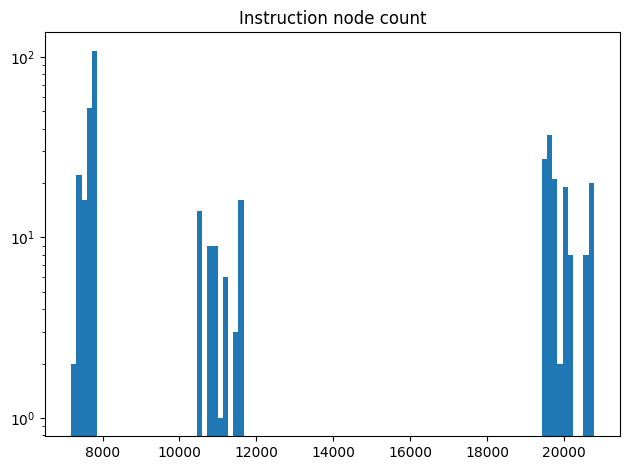

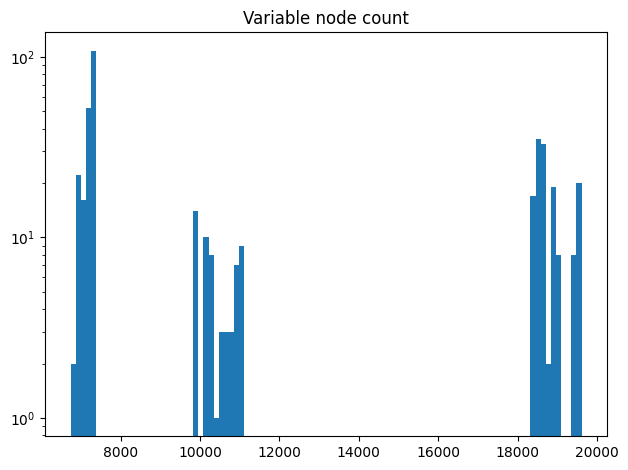

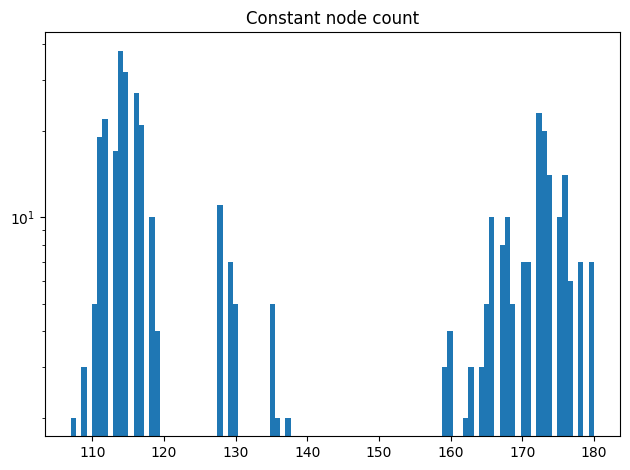

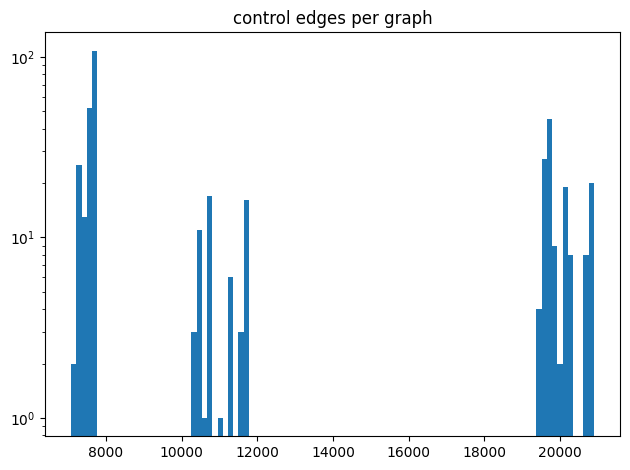

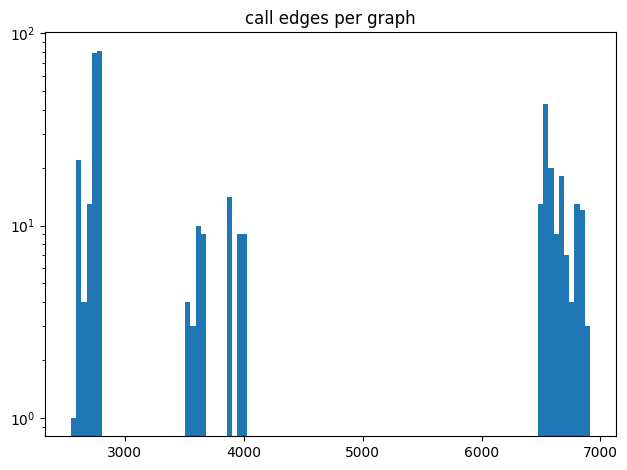

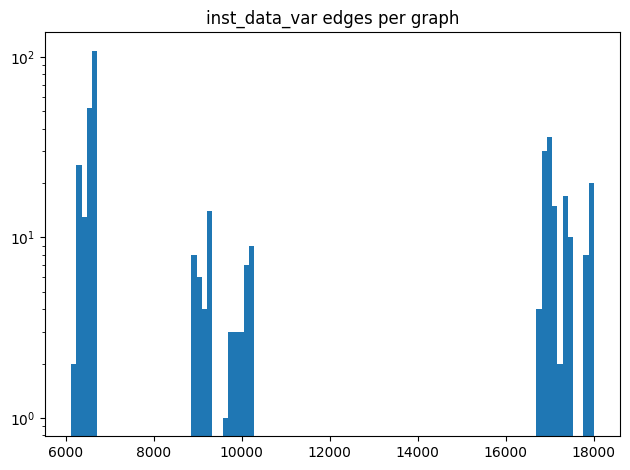

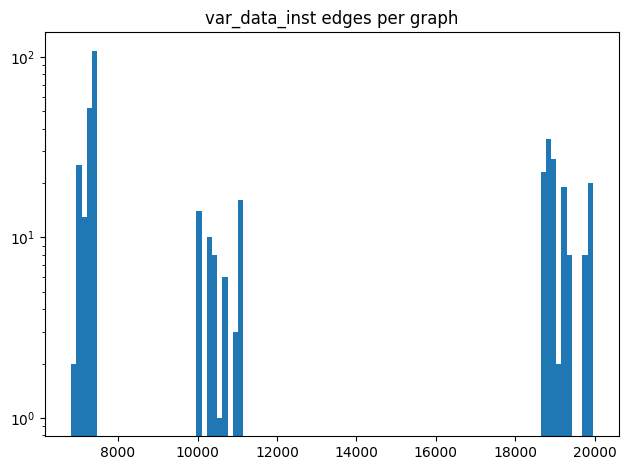

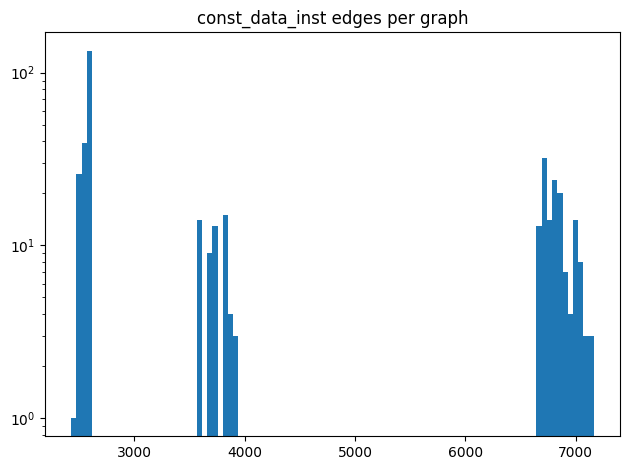

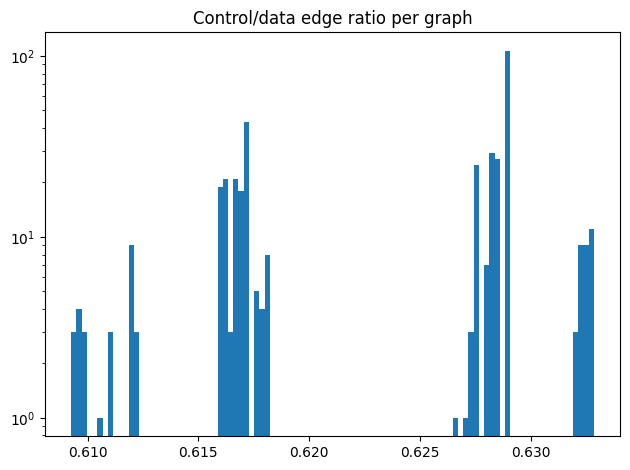

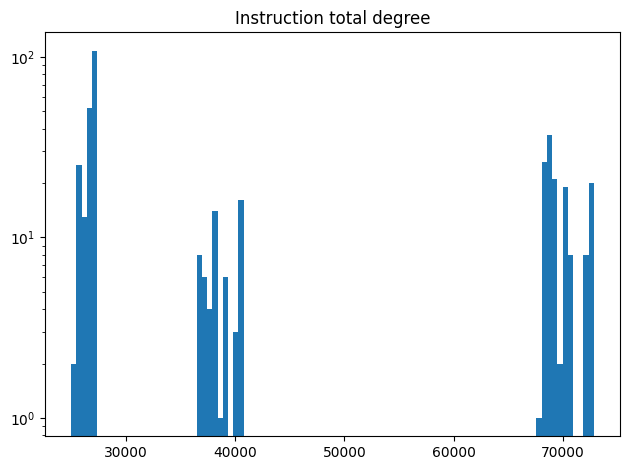

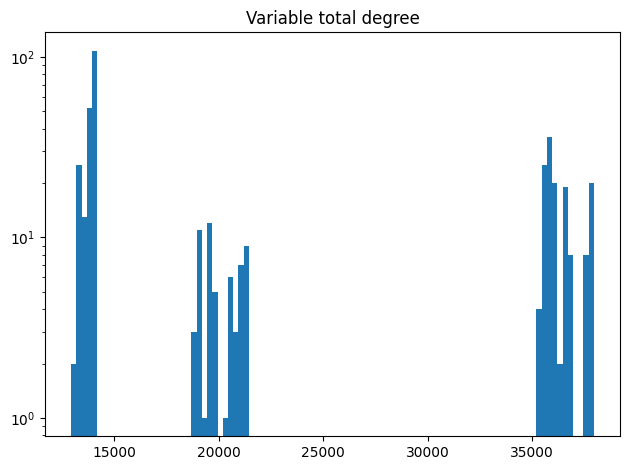

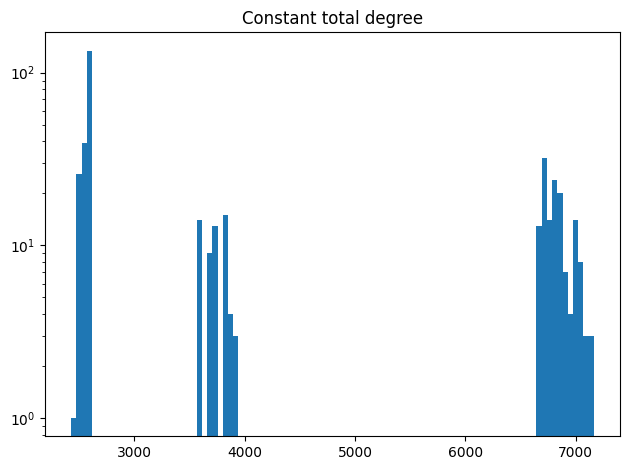

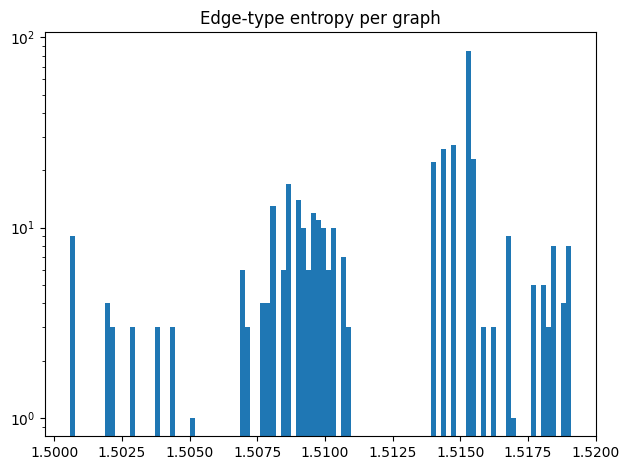

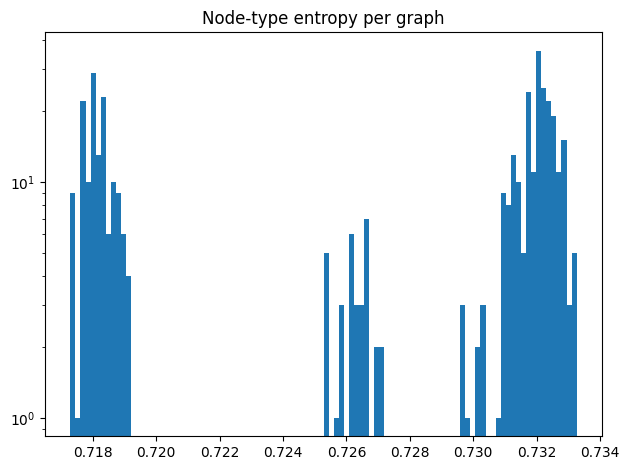

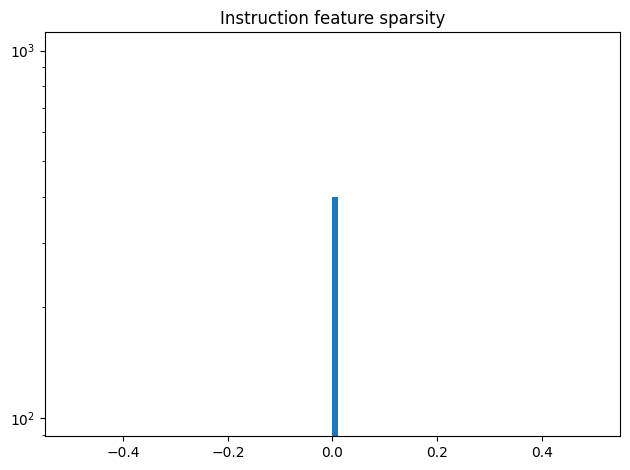

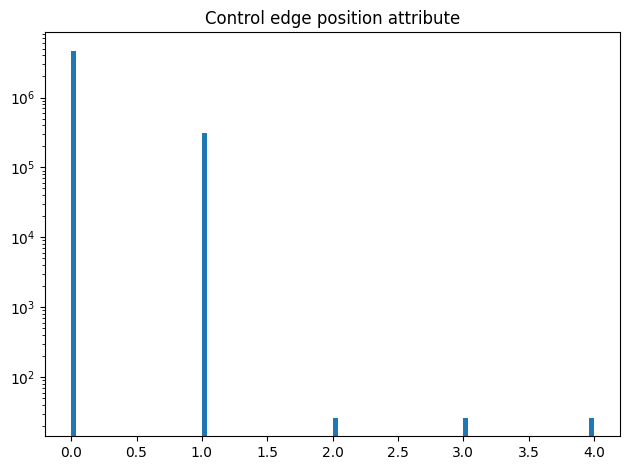

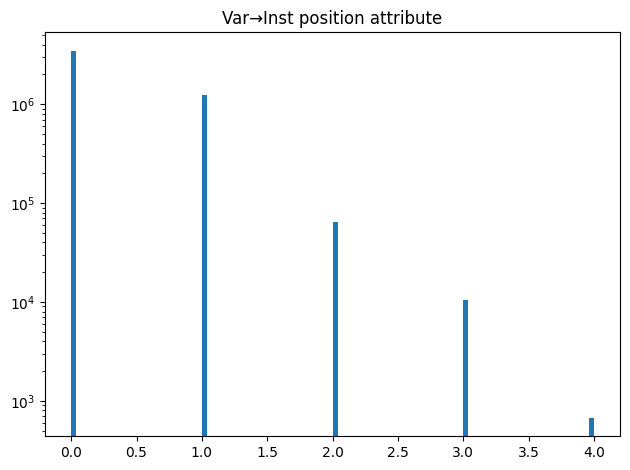

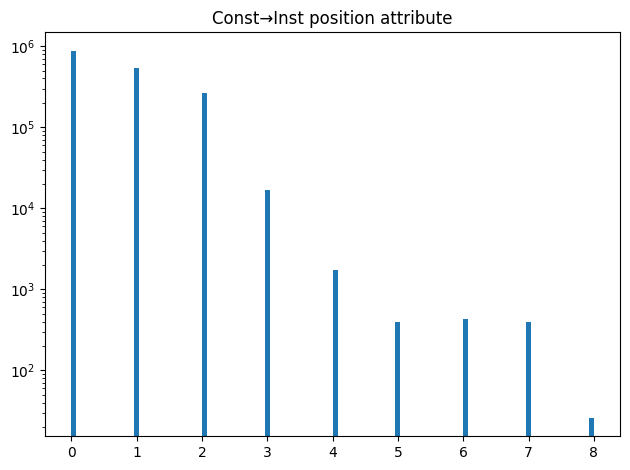

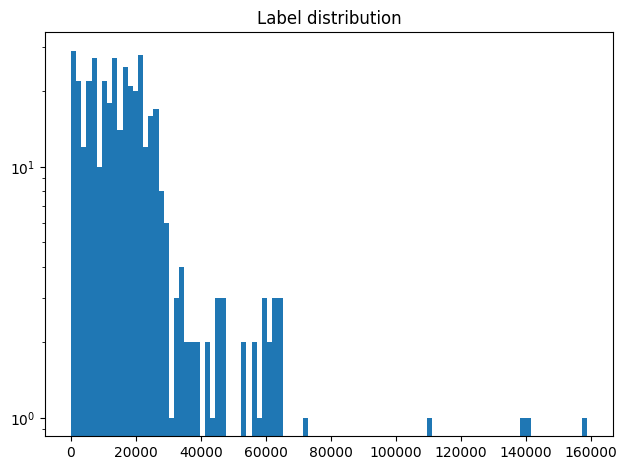

Graphs:               400
Isolated graphs:      0 (0.0%)
Avg instruction nodes:12510.7
Avg variable nodes:   11789.5
Avg constant nodes:   139.5
Avg control edges:    12489.3
Avg data edges:       26987.4
Avg ctrl/data ratio:  0.62
Label distribution: {36.0: 1, 49.0: 1, 74.0: 1, 76.0: 1, 84.0: 1, 85.0: 1, 91.0: 1, 103.0: 1, 122.0: 1, 127.0: 1, 137.0: 1, 383.0: 1, 414.0: 1, 428.0: 1, 483.0: 1, 640.0: 1, 692.0: 1, 717.0: 1, 738.0: 1, 825.0: 1, 842.0: 1, 955.0: 1, 981.0: 1, 1011.0: 1, 1017.0: 1, 1023.0: 1, 1083.0: 1, 1357.0: 1, 1367.0: 1, 1723.0: 1, 2010.0: 1, 2112.0: 1, 2114.0: 1, 2227.0: 1, 2236.0: 1, 2769.0: 1, 2795.0: 1, 2806.0: 1, 2829.0: 1, 2863.0: 1, 2904.0: 1, 2909.0: 1, 2911.0: 1, 2913.0: 2, 3057.0: 2, 3112.0: 1, 3133.0: 1, 3142.0: 1, 3194.0: 1, 3301.0: 1, 3323.0: 1, 3334.0: 1, 3337.0: 4, 3349.0: 1, 3367.0: 1, 3398.0: 1, 4427.0: 1, 4627.0: 1, 4920.0: 1, 4933.0: 1, 4950.0: 1, 5013.0: 1, 5034.0: 1, 5101.0: 1, 5111.0: 1, 5228.0: 1, 5260.0: 1, 5308.0: 1, 5311.0: 1, 5341.0: 1, 5391.0:

In [45]:
importlib.reload(preprocessing)
from preprocessing import analyze_graph_dataset
analyze_graph_dataset(pt_dir)

/tmp/ipykernel_43377/1071102002.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_43377/1071102002.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="token", data=top_instruction, ax=axes[0,1], palette="rocket")
/tmp/ipykernel_43377/1071102002.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="count", y="token", data=top_variable, ax=axes[1,0], palette="viridis")
/tmp/ipykernel_43377/1071102002.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

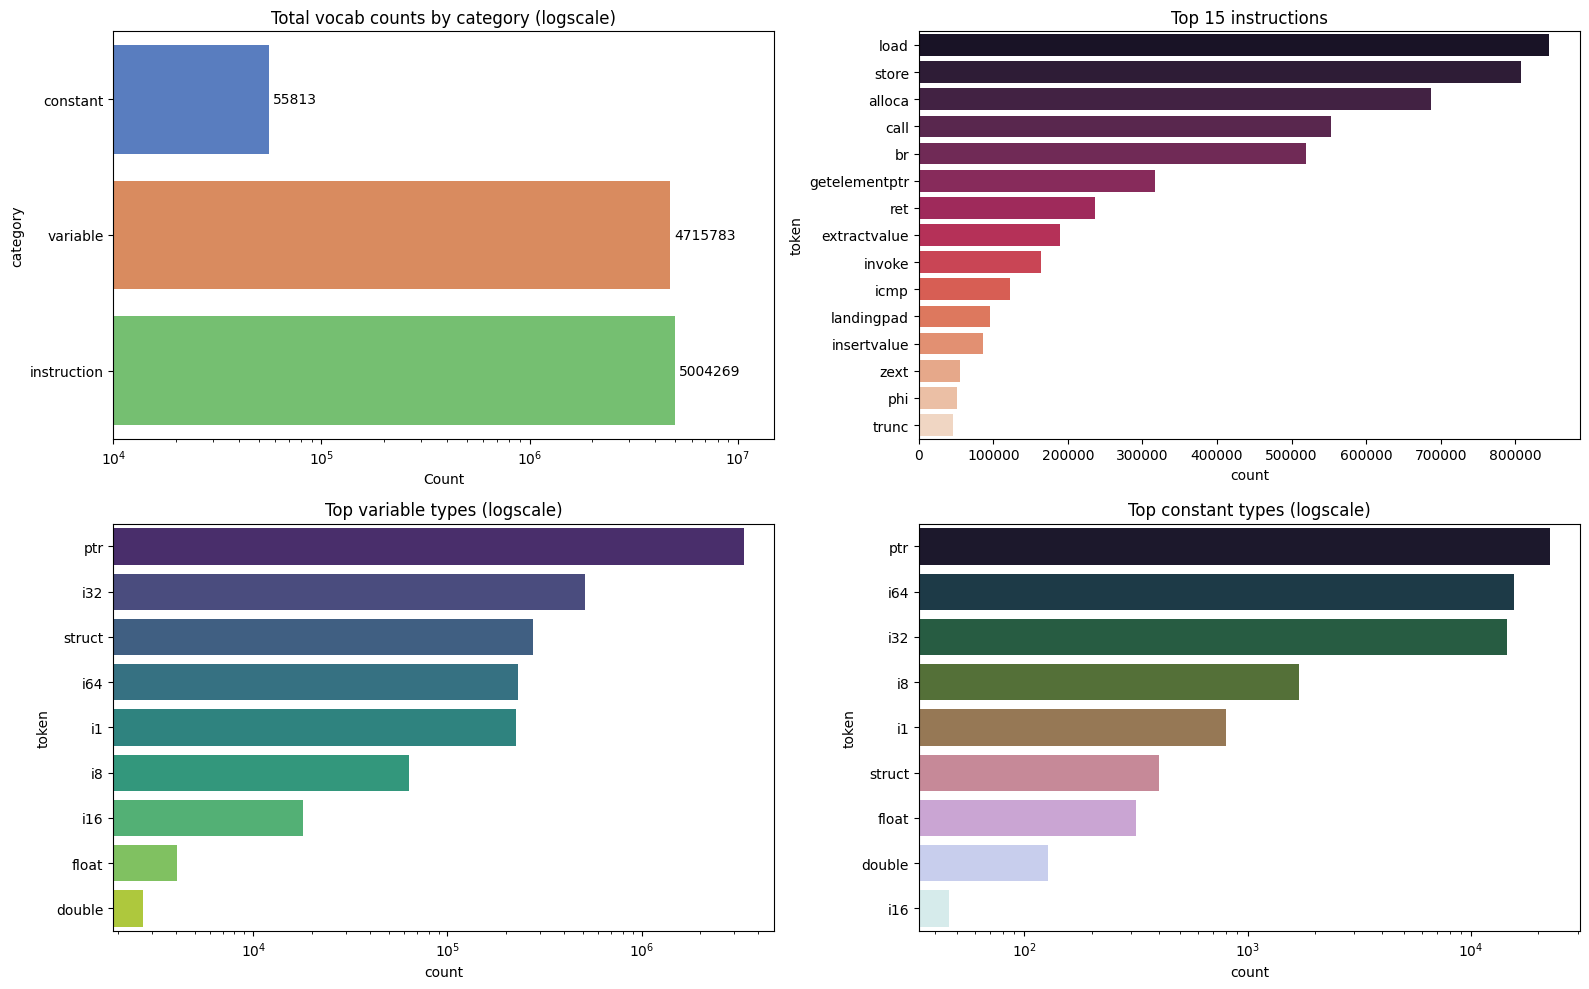

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame([
    {"category": cat, "token": tok, "count": cnt}
    for cat, table in vocab_counts.items()
    for tok, cnt in table.items()
])

totals = df.groupby("category")["count"].sum().sort_values()

top_instruction = (
    df[df["category"] == "instruction"]
    .nlargest(15, "count")
    .sort_values("count", ascending=False)
)
top_variable = (
    df[df["category"] == "variable"]
    .nlargest(10, "count")
    .sort_values("count", ascending=False)
)
top_constant = (
    df[df["category"] == "constant"]
    .nlargest(10, "count")
    .sort_values("count", ascending=False)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax = axes[0,0]

sns.barplot(
    x=totals.values,
    y=totals.index,
    ax=ax,
    palette="muted"
)

ax.set_title("Total vocab counts by category (logscale)")
ax.set_xlabel("Count")
ax.set_xscale("log")
ax.set_xlim(1e4, totals.max() * 3)

# Labels at the end/top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        label_type='edge',
        padding=3
    )

sns.barplot(x="count", y="token", data=top_instruction, ax=axes[0,1], palette="rocket")
axes[0,1].set_title("Top 15 instructions")

sns.barplot(x="count", y="token", data=top_variable, ax=axes[1,0], palette="viridis")
axes[1,0].set_title("Top variable types (logscale)")
axes[1,0].set_xscale("log")

sns.barplot(x="count", y="token", data=top_constant, ax=axes[1,1], palette="cubehelix")
axes[1,1].set_title("Top constant types (logscale)")
axes[1,1].set_xscale("log")

plt.tight_layout()
plt.show()

In [4]:
pprint(vocab_counts)

{'constant': {'double': 128,
              'float': 316,
              'i1': 800,
              'i16': 46,
              'i32': 14412,
              'i64': 15489,
              'i8': 1704,
              'ptr': 22518,
              'struct': 400},
 'instruction': {'; undefined function': 18632,
                 '[external]': 400,
                 'add': 30958,
                 'alloca': 687525,
                 'and': 11864,
                 'ashr': 8289,
                 'br': 518727,
                 'call': 552277,
                 'extractvalue': 189977,
                 'fadd': 32,
                 'fdiv': 206,
                 'fmul': 32,
                 'fneg': 32,
                 'fpext': 206,
                 'fptrunc': 64,
                 'fsub': 32,
                 'getelementptr': 316245,
                 'icmp': 122135,
                 'insertvalue': 86010,
                 'invoke': 163587,
                 'landingpad': 95490,
                 'load': 844635,
       

In [40]:
# open random graph
graphs = list(graph_dir.glob("**/*.json"))
sample_graph = np.random.choice(graphs)
print(f"Sample graph: {sample_graph}\n")
with open(sample_graph) as f:
    data = json.load(f)

# print 5 random nodes
nodes = np.random.choice(data.get("nodes", []), size=5, replace=False)
print("** SAMPLE NODES **")
pprint(nodes)
print()

# print 5 random links
links = np.random.choice(data.get("links", []), size=5, replace=False)
print("** SAMPLE LINKS **")
pprint(links)
print()

# print labels
print("** LABELS **")
pprint(data.get("labels", {}))

Sample graph: ../data/graphs/2layer/archive_1/a59b4b07-6993-4976-b67b-a732f5c95ca7.json

** SAMPLE NODES **
array([{'block': 1477, 'features': {'full_text': ['i64 -9223372036854775808']}, 'function': 0, 'id': 14901, 'text': 'i64', 'type': 2},
       {'block': 1363, 'features': {'full_text': ['store ptr %0, ptr %3, align 8']}, 'function': 414, 'id': 13701, 'text': 'store', 'type': 0},
       {'block': 606, 'features': {'full_text': ['ptr %3']}, 'function': 152, 'id': 5346, 'text': 'ptr', 'type': 1},
       {'block': 1417, 'features': {'full_text': ['%47 = load i32, ptr %15, align 4']}, 'function': 435, 'id': 14420, 'text': 'load', 'type': 0},
       {'block': 1216, 'features': {'full_text': ['store ptr %1, ptr %5, align 8']}, 'function': 362, 'id': 12108, 'text': 'store', 'type': 0}],
      dtype=object)

** SAMPLE LINKS **
array([{'flow': 1, 'key': 0, 'position': 0, 'source': 9074, 'target': 9085},
       {'flow': 1, 'key': 0, 'position': 1, 'source': 1656, 'target': 1654},
       {'fl

## Data Loading

In [41]:
graphs = list(graph_dir.glob("**/*.json"))
sample_graph = np.random.choice(graphs)
file_stem = sample_graph.parts[-3] + "/" + sample_graph.parts[-2] + "/" + sample_graph.stem
print(f"Sample graph: {file_stem}\n")
# Load tensor from .pt file
data = torch.load(Path("../data/tensors") / Path(f"{file_stem}.pt"), weights_only=False)
print(f"Graph label: {data.y.item()}")
print(data)
print(f"First 5 entries of instruction node features:\n{data['instruction'].x[:5]}")
print(f"First 5 entries of variable node features:\n{data['variable'].x[:5]}")
print(f"First 5 entries of constant node features:\n{data['constant'].x[:5]}")

# Load original .json
with Path(f"../data/graphs/{file_stem}.json").open('r') as f:
    graph_data = json.load(f)

nodes = {
    "total": len(graph_data.get('nodes', [])),
    "instruction": 0,
    "variable": 0,
    "constant": 0
}

edges = {
    "total": len(graph_data.get('links', [])),
    "control": 0,
    "data_var": 0,
    "data_const": 0,
    "call": 0
}

for n in graph_data.get('nodes', []):
    node_type = n.get('type', -1)
    if node_type == 0:
        nodes["instruction"] += 1
    elif node_type == 1:
        nodes["variable"] += 1
    elif node_type == 2:
        nodes["constant"] += 1
    else:
        print(f"Unknown node type: {node_type}")

print(f"Node counts: {nodes}")

# figure out which way data edges point
flows = {}
positional = {}
type_dict = {0: "instruction", 1: "variable", 2: "constant"}
flow_dict = {0: "control", 1: "data", 2: "call"}
types = [0, 1, 2]
for l in graph_data.get("links", []):
    flow = l.get("flow")
    source = l.get("source")
    target = l.get("target")
    position = l.get("position", -1)
    source_type = graph_data["nodes"][source]["type"]
    target_type = graph_data["nodes"][target]["type"]
    if flows.get((flow_dict[flow], type_dict[source_type], type_dict[target_type])) is None:
        flows[flow_dict[flow], type_dict[source_type], type_dict[target_type]] = 1
    else:
        flows[flow_dict[flow], type_dict[source_type], type_dict[target_type]] += 1
    if position != -1 and position != 0:
        positional[flow_dict[flow], type_dict[source_type], type_dict[target_type]] = True
print("Edge counts:")
pprint(flows)
print("Positional edges:")
pprint(positional)

Sample graph: 2layer/archive_1/f03929b4-833f-4c91-a2f4-603b7bd8773f

Graph label: 17083.0
HeteroData(
  y=[1],
  instruction={ x=[7495, 1] },
  variable={ x=[7031, 1] },
  constant={ x=[112, 1] },
  (instruction, control, instruction)={
    edge_index=[2, 7374],
    edge_attr=[7374, 1],
  },
  (instruction, data, variable)={ edge_index=[2, 6381] },
  (variable, data, instruction)={
    edge_index=[2, 7115],
    edge_attr=[7115, 1],
  },
  (constant, data, instruction)={
    edge_index=[2, 2534],
    edge_attr=[2534, 1],
  },
  (instruction, call, instruction)={ edge_index=[2, 2695] }
)
First 5 entries of instruction node features:
tensor([[ 2],
        [ 4],
        [ 4],
        [ 7],
        [26]])
First 5 entries of variable node features:
tensor([[8],
        [8],
        [8],
        [8],
        [3]])
First 5 entries of constant node features:
tensor([[5],
        [5],
        [5],
        [8],
        [8]])
Node counts: {'total': 14638, 'instruction': 7495, 'variable': 7031, 'co

In [20]:
from torch_geometric.loader import DataLoader as PyGDataLoader

def make_loader(ds, batch_size, shuffle=True):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    return PyGDataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=False, ############################################# change
        persistent_workers=True,  # avoid worker respawn overhead
        #prefetch_factor=4,  # Load 4 batches ahead
    )

## Model Architecture

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import RGCNConv, HeteroConv, GraphConv, SAGEConv
from torch_geometric.data import HeteroData
from torch_geometric.nn import global_mean_pool, global_add_pool, global_max_pool


# ── Meta ────────────────────────────────────────────────────────────────────
NODE_TYPES   = ["instruction", "variable", "constant"]
EDGE_TYPES   = [
    ("instruction", "control", "instruction"),
    ("instruction", "data",    "variable"),
    ("variable",    "data",    "instruction"),
    ("constant",    "data",    "instruction"),
    ("instruction", "call",    "instruction"),
]
EDGE_TYPES_WITH_ATTR = {   # edge types that carry a positional arg encoding
    ("instruction", "control", "instruction"),
    ("variable",    "data",    "instruction"),
    ("constant",    "data",    "instruction"),
}


# ── Input projection ────────────────────────────────────────────────────────
class CDFGInputProjection(nn.Module):
    """
    Embeds the last feature dimension (opcode / type vocab) for each node type,
    and the positional-argument encoding for data edges.

    Node feature layout: [vocab_id]         (int-like)
    Edge attr layout:    [arg_position]     (int-like)
    """
    def __init__(
        self,
        node_vocab_sizes: dict[str, int],  # {node_type: vocab_size}
        edge_pos_vocab_size: int,          # max arg-position value + 1
        hidden_dim: int,
    ):
        super().__init__()
        # One embedding table per node type (embeds the vocab/opcode feature)
        self.node_emb = nn.ModuleDict({
            nt: nn.Embedding(vocab_size + 1, hidden_dim, padding_idx=0)
            for nt, vocab_size in node_vocab_sizes.items()
        })
        # Single shared embedding for arg-position across both data edge types
        self.edge_pos_emb = nn.Embedding(edge_pos_vocab_size + 1, hidden_dim, padding_idx=0)

    def forward(self, x_dict, edge_attr_dict):
        """
        x_dict:         {node_type: LongTensor [N, 1]}
        edge_attr_dict: {edge_type: LongTensor [E, 1]}

        Returns:
            h_dict:          {node_type: FloatTensor [N, hidden_dim]}
            edge_emb_dict:   {edge_type: FloatTensor [E, hidden_dim]}
        """
        h_dict = {
            nt: self.node_emb[nt](x[:, 0])
            for nt, x in x_dict.items()
        }
        edge_emb_dict = {
            et: self.edge_pos_emb(attr[:, 0])
            for et, attr in edge_attr_dict.items()
        }
        return h_dict, edge_emb_dict


# ── Single R-GCN layer (heterogeneous) ──────────────────────────────────────
class CDFGConvLayer(nn.Module):
    """
    One message-passing step over all edge types.

    For data edges (which carry positional encodings) the edge embedding is
    added to the source-node representation before aggregation.
    """
    def __init__(self, hidden_dim: int, aggr: str = "mean"):
        super().__init__()
        self.conv = HeteroConv({
            et: SAGEConv(
                in_channels=(hidden_dim, hidden_dim),  # (src, dst) dims
                out_channels=hidden_dim,
                aggr=aggr,
            )
            for et in EDGE_TYPES
        }, aggr="mean")  # how to combine multiple edge types into same dst
        self.norm = nn.ModuleDict({
            nt: nn.LayerNorm(hidden_dim) for nt in NODE_TYPES
        })

    def forward(self, h_dict, edge_index_dict, edge_emb_dict):
        # Work on a shallow copy so we don't mutate the input
        h = {nt: h_dict[nt] for nt in NODE_TYPES}

        # Add positional encoding into source node features before conv
        # for et in EDGE_TYPES_WITH_ATTR:
        #     if et not in edge_emb_dict:
        #         continue
        #     src_type = et[0]
        #     src_indices = edge_index_dict[et][0]       # which src nodes have edges
        #     pos_emb = edge_emb_dict[et]                # [E, hidden_dim]
        #     h[src_type] = h[src_type].clone()          # don't mutate the original tensor
        #     h[src_type].index_add_(0, src_indices, pos_emb)

        out = self.conv(h, edge_index_dict)

        # HeteroConv only outputs node types that appear as destinations
        # carry forward any missing node types unchanged
        for nt in NODE_TYPES:
            if nt not in out:
                out[nt] = h_dict[nt]  # unchanged from input

        return {nt: self.norm[nt](F.relu(h_out)) for nt, h_out in out.items()}


# ── Full R-GCN ───────────────────────────────────────────────────────────────
class CDFGRGCN(nn.Module):
    """
    Heterogeneous R-GCN for LLVM CDFG graphs.

    Args:
        node_vocab_sizes:    {node_type: vocab_size}
        edge_pos_vocab_size: max arg-position value seen in training data
        hidden_dim:          width of all hidden representations
        num_layers:          number of message-passing steps
        num_classes:         output classes (graph-level prediction)
        dropout:             applied before the classifier
        pool:                "mean" | "sum" | "max"  — graph-level pooling
        aggr:                RGCNConv neighbour aggregation: "sum" | "mean"
    """
    def __init__(
        self,
        node_vocab_sizes:    dict[str, int],
        edge_pos_vocab_size: int,
        hidden_dim:          int  = 128,
        num_layers:          int  = 3,
        dropout:             float = 0.1,
        pool:                str  = "mean",
        aggr:                str  = "mean",
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.pool       = pool

        self.input_proj = CDFGInputProjection(
            node_vocab_sizes, edge_pos_vocab_size, hidden_dim
        )
        self.layers = nn.ModuleList([
            CDFGConvLayer(hidden_dim, aggr=aggr)
            for _ in range(num_layers)
        ])
        self.dropout    = nn.Dropout(dropout)
        # Graph-level head: concatenate pooled repr of all 3 node types
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * len(NODE_TYPES), hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1), # just predicting LUTs for now
        )

    def _pool(self, h: torch.Tensor) -> torch.Tensor:
        if self.pool == "mean":
            return h.mean(dim=0)
        elif self.pool == "sum":
            return h.sum(dim=0)
        elif self.pool == "max":
            return h.max(dim=0).values
        raise ValueError(self.pool)

    def forward(self, data: HeteroData):
        x_dict          = {nt: data[nt].x.long() for nt in NODE_TYPES}
        edge_index_dict = {et: data[et].edge_index for et in EDGE_TYPES}
        edge_attr_dict  = {
            et: data[et].edge_attr.long()
            for et in EDGE_TYPES_WITH_ATTR
            if hasattr(data[et], "edge_attr") and data[et].edge_attr is not None
        }

        # 1. Input embeddings
        h_dict, edge_emb_dict = self.input_proj(x_dict, edge_attr_dict)

        # 2. Message passing
        for layer in self.layers:
            h_dict = layer(h_dict, edge_index_dict, edge_emb_dict)
            # Apply dropout between layers (not after the last)
            if layer is not self.layers[-1]:
                h_dict = {nt: self.dropout(h) for nt, h in h_dict.items()}

        # 3. Graph-level pooling per node type → concat → classify
        pool_fn = {
            "mean": global_mean_pool,
            "sum":  global_add_pool,
            "max":  global_max_pool,
        }[self.pool]

        pooled = torch.cat([
            pool_fn(h_dict[nt], data[nt].batch)
            for nt in NODE_TYPES
        ], dim=-1)  # [batch_size, hidden_dim * 3]
        return self.classifier(pooled)

## Model Training

In [23]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

def to_luts(pred, y_mean, y_std):
    return torch.expm1(pred * y_std + y_mean)

In [24]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, y_mean, y_std):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        y_mean (float): Mean of the log-transformed target variable in the training set (for normalization)
        y_std (float): Standard deviation of the log-transformed target variable in the training set (for normalization)

    Returns:
        float: average_loss - Training loss for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0

    # Iterate through training batches
    for batch in train_loader:
        batch = batch.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        target = (torch.log1p(batch.y) - y_mean.to(device)) / y_std.to(device)

        pred = model(batch).squeeze(-1)          # [B, 1]
        loss   = criterion(pred, target)
        loss.backward()

        # Accumulate metrics
        running_loss += loss.item()

        optimizer.step()


    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader)

    return epoch_loss

In [25]:
from scipy.stats import pearsonr

def validate_one_epoch(model, val_loader, criterion, device, y_mean, y_std):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        y_mean (float): Mean of the log-transformed target variable in the training set (for normalization)
        y_std (float): Standard deviation of the log-transformed target variable in the training set (for normalization)

    Returns:
        float: average_loss - Validation loss for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    all_preds, all_targets = [], []
    running_loss = 0.0

    # Disable gradient computation for validation
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)

            target = (torch.log1p(batch.y) - y_mean.to(device)) / y_std.to(device)

            pred = model(batch).squeeze(-1)
            loss = criterion(pred, target)

            # Accumulate metrics
            all_preds.append(pred.cpu())
            all_targets.append(target.cpu())
            running_loss += loss.item()

    # Calculate epoch metrics
    preds = torch.cat(all_preds)
    targets = torch.cat(all_targets)
    r, _ = pearsonr(preds.numpy(), targets.numpy())
    epoch_loss = running_loss / len(val_loader)

    return epoch_loss, r, preds.std(), targets.std()

In [27]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, device, y_mean, y_std,
        patience=0, evaluation_metric="val_loss", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        y_mean (float): Mean of the log-transformed target variable in the training set (for normalization)
        y_std (float): Standard deviation of the log-transformed target variable in the training set (for normalization)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_loss")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss = train_one_epoch(
            model, train_loader, criterion, optimizer, device, y_mean, y_std
        )

        # Evaluate model on validation data without updating weights
        val_loss, r, preds_std, targets_std = validate_one_epoch(
            model, val_loader, criterion, device, y_mean, y_std
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f} | "
                    f"Val: Loss={val_loss:.4f}, R={r:.4f}, pred std={preds_std:.4f}, target std={targets_std:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    return model, training_history

In [18]:
from datasets import HeteroGraphDataset
from torch.utils.data import random_split, Subset

# Specific types only
dataset = HeteroGraphDataset(
    root="../data/tensors",
    types=["2layer", "exemplar"],
)

# Random split
n = len(dataset)
train_ds, val_ds, test_ds = random_split(
    dataset, [int(0.8*n), int(0.2*n), 0]
)

# # Or split by type (cleaner for generalization testing)
# def split_by_type(dataset, val_types, test_types):
#     train_idx, val_idx, test_idx = [], [], []
#     for i, path in enumerate(dataset.paths):
#         t = path.parts[-3]
#         if t in test_types:
#             test_idx.append(i)
#         elif t in val_types:
#             val_idx.append(i)
#         else:
#             train_idx.append(i)
#     return Subset(dataset, train_idx), Subset(dataset, val_idx), Subset(dataset, test_idx)

# train_ds, val_ds, test_ds = split_by_type(
#     dataset,
#     val_types=["exemplar"],
#     test_types=[],
# )

Indexed 400 graphs across 2 type(s)


In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
#device = "cpu"
train_loader = make_loader(train_ds, batch_size=16, shuffle=True)
val_loader   = make_loader(val_ds, batch_size=16, shuffle=False)

vocab_sizes = {k: len(v) for k, v in vocab.items()}

model = CDFGRGCN(
    node_vocab_sizes=vocab_sizes,
    edge_pos_vocab_size=max_pos + 16,
    hidden_dim=128,
    num_layers=5,
    dropout=0.1,
    pool="mean",
).to(device)
#model.compile()
torch.set_float32_matmul_precision('high')
torch._dynamo.config.capture_scalar_outputs = True

train_ys = torch.tensor([data.y for data in train_ds])
log_ys = torch.log1p(train_ys)
y_mean = log_ys.mean()
y_std = log_ys.std()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

/tmp/ipykernel_43377/859518942.py:79: UserWarning: There exist node types ({'constant'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv = HeteroConv({


In [29]:
train_targets = []
val_targets = []

for g in train_ds:
    train_targets.append(torch.log1p(g.y))

for g in val_ds:
    val_targets.append(torch.log1p(g.y))

train_targets = torch.cat(train_targets)
val_targets = torch.cat(val_targets)

print(train_targets.mean(), train_targets.std())
print(val_targets.mean(), val_targets.std())

tensor(9.3470) tensor(1.2037)
tensor(9.2072) tensor(1.5555)


In [72]:
# LOAD MODEL
model.load_state_dict(
    torch.load("models/" + "cdfg_rgcn_experiment" + "_model.pt", map_location=device)
)

<All keys matched successfully>

In [79]:
model, training_history = fit(
    model,
    train_loader,
    val_loader,
    epochs=100,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    y_mean=y_mean,
    y_std=y_std,
    patience=0,
    evaluation_metric="val_loss",
    mode='min',
    restore_best_weights=True,
    writer=None,  # Add TensorBoard writer if needed
    verbose=1,
    experiment_name="cdfg_rgcn_experiment"
)

Training 100 epochs...


Epoch   1/100 | Train: Loss=1.0721 | Val: Loss=0.6367, R=0.3379, pred std=0.0064, target std=0.7813
Epoch   2/100 | Train: Loss=1.0331 | Val: Loss=0.6234, R=0.2199, pred std=0.0085, target std=0.7813
Epoch   3/100 | Train: Loss=1.0032 | Val: Loss=0.5996, R=0.3265, pred std=0.0129, target std=0.7813
Epoch   4/100 | Train: Loss=0.9944 | Val: Loss=0.6119, R=0.3998, pred std=0.0155, target std=0.7813
Epoch   5/100 | Train: Loss=1.0247 | Val: Loss=0.6157, R=0.3838, pred std=0.0143, target std=0.7813
Epoch   6/100 | Train: Loss=0.9921 | Val: Loss=0.5925, R=0.3965, pred std=0.0172, target std=0.7813
Epoch   7/100 | Train: Loss=1.0093 | Val: Loss=0.6032, R=0.4324, pred std=0.0156, target std=0.7813
Epoch   8/100 | Train: Loss=1.0030 | Val: Loss=0.6044, R=0.4789, pred std=0.0104, target std=0.7813
Epoch   9/100 | Train: Loss=0.9952 | Val: Loss=0.5917, R=0.4884, pred std=0.0150, target std=0.7813
Epoch  10/100 | Train: Loss=0.9976 | Val: Loss=0.6064, R=0.4993, pred std=0.0156, target std=0.7813


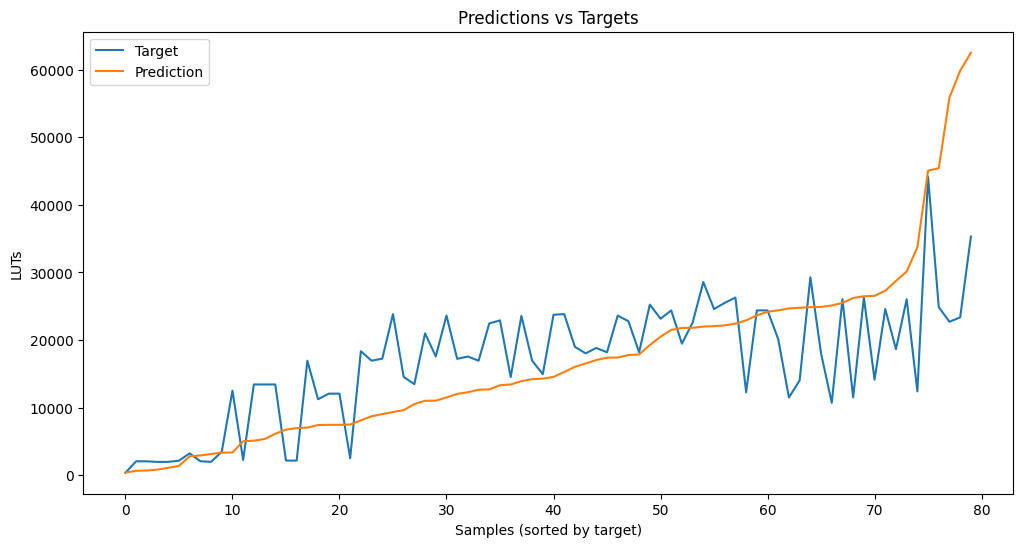

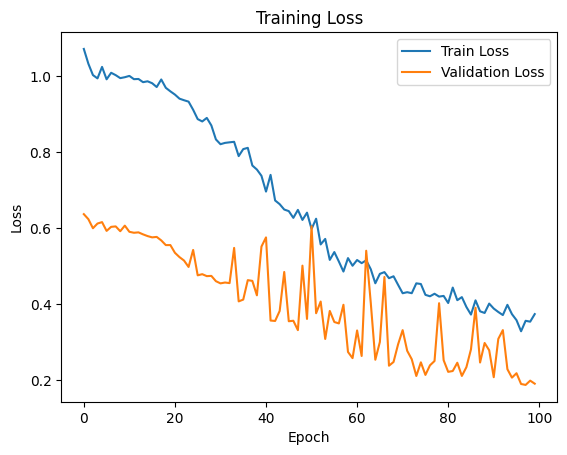

In [86]:
import matplotlib.pyplot as plt
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)

        preds = to_luts(
            model(batch).squeeze(-1),
            y_mean.to(device),
            y_std.to(device)
        )

        all_preds.append(preds.cpu())
        all_targets.append(batch.y.cpu())

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

# Sort by target value
sort_idx = all_targets.argsort()

sorted_targets = all_targets[sort_idx]
sorted_preds = all_preds[sort_idx]

plt.figure(figsize=(12, 6))

plt.plot(sorted_preds, label="Target")
plt.plot(sorted_targets, label="Prediction")

plt.xlabel("Samples (sorted by target)")
plt.ylabel("LUTs")
plt.title("Predictions vs Targets")
plt.legend()

plt.show()

plt.figure()
plt.plot(training_history['train_loss'], label='Train Loss')
plt.plot(training_history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

In [50]:
for k, v in vocab.items():
    print(f"{k}: vocab size={len(v)}")

for i, batch in enumerate(train_loader):
    for nt in NODE_TYPES:
        print(f"batch {i}, {nt}: num_nodes={batch[nt].x.shape[0]}, "
              f"unique x values={batch[nt].x.unique().shape[0]}")
        #print(f"  x sample: {batch[nt].x[:5, 0].cpu().numpy()}")
    for et in EDGE_TYPES:
        if hasattr(batch[et], 'edge_index'):
            print(f"  {et}: num_edges={batch[et].edge_index.shape[1]}")
        else:
            print(f"  {et}: NO EDGES")
    if i >= 2:
        break

instruction: vocab size=43
variable: vocab size=9
constant: vocab size=9
batch 0, instruction: num_nodes=137933, unique x values=42
batch 0, variable: num_nodes=130087, unique x values=9
batch 0, constant: num_nodes=1294, unique x values=9
  ('instruction', 'control', 'instruction'): num_edges=138143
  ('instruction', 'data', 'variable'): num_edges=118967
  ('variable', 'data', 'instruction'): num_edges=132222
  ('constant', 'data', 'instruction'): num_edges=47347
  ('instruction', 'call', 'instruction'): num_edges=46498
batch 1, instruction: num_nodes=89418, unique x values=36
batch 1, variable: num_nodes=84262, unique x values=9
batch 1, constant: num_nodes=1066, unique x values=8
  ('instruction', 'control', 'instruction'): num_edges=89207
  ('instruction', 'data', 'variable'): num_edges=77030
  ('variable', 'data', 'instruction'): num_edges=85418
  ('constant', 'data', 'instruction'): num_edges=30350
  ('instruction', 'call', 'instruction'): num_edges=30519
batch 2, instruction: nu